# Mid-Training、退火与持续预训练

> 我们已经知道怎么训练一个 LLM，缩放定律告诉我们模型和数据怎么配比，数据工程告诉我们训练数据从哪来。但预训练不是终点——训练完之后，还有一系列策略可以让模型效果再上一个台阶。
>
> 这一节，我们学习 2024 年最重要的训练策略：WSD 调度器让训练可以随时续，退火让最后阶段的算力发挥最大效用，持续预训练把通用模型变成领域专家。

传统的 Cosine 学习率调度器有一个根本缺陷：训练步数必须提前定死，中途想续训，学习率曲线不连续，模型可能直接训崩。WSD（Warmup-Stable-Decay）调度器把训练分成三段——热身、稳定、衰减——其中 Stable 阶段学习率恒定，可以随时延长训练。退火则借鉴了冶金学的思想：训练最后阶段逐步降低学习率，让模型参数从「粗略收敛」走向「精细排列」。持续预训练（CPT）是退火思路的延伸：让通用模型在特定领域数据上继续训练，同时用数据混合和 LoRA 冻结防止遗忘。下面逐一拆开。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. 一个问题引出整个 Part

假设你用 Cosine 学习率调度器训了一个 7B 模型，训了 1T tokens。训完后你发现：如果再加 500B tokens，loss 应该还能降。

**但问题来了：**

Cosine 调度器的学习率曲线是先升后降，像一个倒扣的碗。使用它之前，你必须提前确定总训练步数 T——调度器按照 T 规划什么时候开始降学习率。当你训到 T 时，学习率已经降到接近 0。

现在想续训？学习率已经降到底了——参数更新量几乎为零，训了等于没训。模型已经跑完了预设步数，但数据还没用完，继续训练的代价是重新调整学习率——而 Cosine 曲线已经降到底了，无法重新升高。

这就是 Cosine 调度器的结构性缺陷：它假设你在训练开始前就知道什么时候结束。但实际训练中，「训到什么时候该停」往往不是事先能确定的——loss 还在降就想继续训，效果不好就想提前停。Cosine 不支持这种灵活性。

2024 年 MiniCPM 团队提出了解决方案：WSD 调度器。</cell>


## 2. WSD 调度器：让训练「随时可以续」

### 2.1 三阶段：热身 → 恒定 → 退火

WSD 把训练分成三段：

```
         Warmup    │     Stable (恒定)    │  Decay (退火)
  η_max ────┐     │                      │
            /      │                      │
           /       │                      │    \
          /        │                      │     \
  0 ─────┘         │                      │      ──
       前 5%       │      中间 80-85%     │   最后 10-15%
```

| 阶段 | LR 变化 | 用时 | 做什么 |
|:---|:---|:---|:---|
| Warmup | 0 → 最大值 | 前 5% 步数 | 让模型「热身」，别一上来就大步走 |
| Stable | **恒定不变** | 中间 80-85% | **满速训练**，随时可停 |
| Decay | 最大值 → 0 | 最后 10-15% | 「退火」，精细调整 |

核心创新在 **Stable 阶段**：LR 恒定不变 → 训练的任何时候都是「满血」状态。
这意味着：
- 你可以从 Stable 阶段的任何一个 checkpoint 开始做 Decay
- 你可以无限续训——想训多久训多久，最后做一个 Decay 收尾
- 你不需要提前知道总训练量

In [2]:
# === Cosine vs WSD 手算对比 ===
print("=== Cosine vs WSD：关键位置的 LR 对比 ===")
print()

T = 1000
warmup = 50
stable_end = 850
eta_max = 0.01

def cosine_lr(t):
    """Cosine: warmup 后立刻开始降"""
    if t < warmup:
        return eta_max * t / warmup
    progress = (t - warmup) / (T - warmup)
    return eta_max * 0.5 * (1 + np.cos(np.pi * progress))

def wsd_lr(t):
    """WSD: warmup → stable(恒定) → decay"""
    if t < warmup:
        return eta_max * t / warmup
    elif t < stable_end:
        return eta_max  # 恒定！
    else:
        progress = (t - stable_end) / (T - stable_end)
        return eta_max * (0.001 ** progress)

print(f"{'步数':>6s}  {'阶段':>8s}  {'Cosine LR':>12s}  {'WSD LR':>12s}  {'差异'}")
print("-" * 60)

for t in [0, 50, 200, 500, 700, 850, 900, 950, 999]:
    if t < warmup:
        phase = "Warmup"
    elif t < stable_end:
        phase = "Stable"
    else:
        phase = "Decay"
    
    cos = cosine_lr(t)
    wsd = wsd_lr(t)
    diff = f"WSD 是 Cosine 的 {wsd/cos:.1f}x" if cos > 0 else "—"
    print(f"{t:>6d}  {phase:>8s}  {cos:>12.6f}  {wsd:>12.6f}  {diff}")

print()
print("关键观察：")
print("  第 500 步：Cosine 已经降到 0.004，WSD 还是满血 0.01")
print("  第 700 步：Cosine 只剩 0.001，WSD 依然满血")
print("  → Cosine 的训练越来越慢，WSD 一直在全速前进")
print()
print("结论：想续训？WSD 随时可以。Cosine？LR 已经降到地板了。")

=== Cosine vs WSD：关键位置的 LR 对比 ===

    步数        阶段     Cosine LR        WSD LR  差异
------------------------------------------------------------
     0    Warmup      0.000000      0.000000  —
    50    Stable      0.010000      0.010000  WSD 是 Cosine 的 1.0x
   200    Stable      0.009397      0.010000  WSD 是 Cosine 的 1.1x
   500    Stable      0.005413      0.010000  WSD 是 Cosine 的 1.8x
   700    Stable      0.002265      0.010000  WSD 是 Cosine 的 4.4x
   850     Decay      0.000603      0.010000  WSD 是 Cosine 的 16.6x
   900     Decay      0.000271      0.001000  WSD 是 Cosine 的 3.7x
   950     Decay      0.000068      0.000100  WSD 是 Cosine 的 1.5x
   999     Decay      0.000000      0.000010  WSD 是 Cosine 的 383.0x

关键观察：
  第 500 步：Cosine 已经降到 0.004，WSD 还是满血 0.01
  第 700 步：Cosine 只剩 0.001，WSD 依然满血
  → Cosine 的训练越来越慢，WSD 一直在全速前进

结论：想续训？WSD 随时可以。Cosine？LR 已经降到地板了。


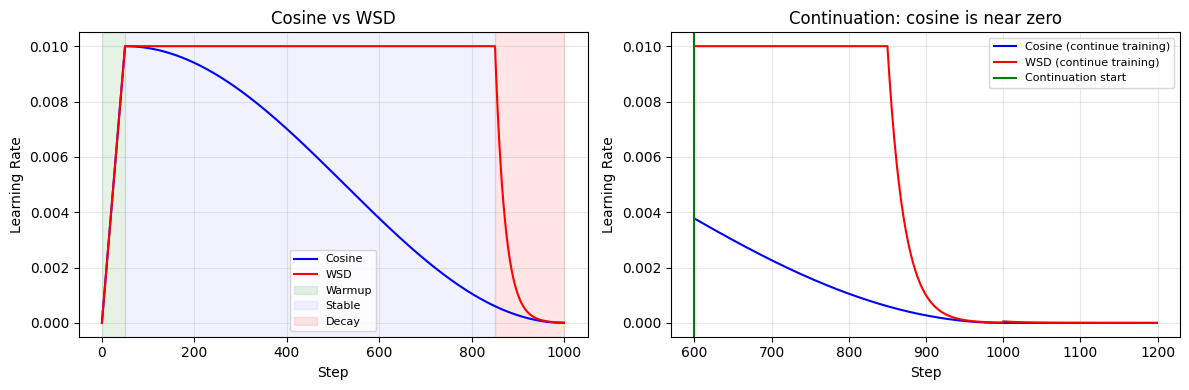

左：WSD 在 85% 的时间里保持满速
右：续训时 Cosine 几乎没有 LR，WSD 依然全速前进


In [3]:
# === 可视化：Cosine vs WSD ===
steps = np.arange(T)
cos_lrs = [cosine_lr(t) for t in steps]
wsd_lrs = [wsd_lr(t) for t in steps]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：正常训练
ax = axes[0]
ax.plot(steps, cos_lrs, 'b-', lw=1.5, label='Cosine')
ax.plot(steps, wsd_lrs, 'r-', lw=1.5, label='WSD')
ax.axvspan(0, warmup, alpha=0.1, color='green', label='Warmup')
ax.axvspan(warmup, stable_end, alpha=0.05, color='blue', label='Stable')
ax.axvspan(stable_end, T, alpha=0.1, color='red', label='Decay')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Cosine vs WSD')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 右图：续训场景
ax = axes[1]
ext = np.arange(600, 1200)
cos_ext = [cosine_lr(min(t, T-1)) for t in ext]  # Cosine 已经降到 0
wsd_ext = [wsd_lr(t) if t < T else eta_max * (0.001 ** ((t - stable_end) / 200)) for t in ext]
ax.plot(ext, cos_ext, 'b-', lw=1.5, label='Cosine (continue training)')
ax.plot(ext, wsd_ext, 'r-', lw=1.5, label='WSD (continue training)')
ax.axvline(x=600, color='green', lw=1.5, label='Continuation start')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Continuation: cosine is near zero')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("左：WSD 在 85% 的时间里保持满速")
print("右：续训时 Cosine 几乎没有 LR，WSD 依然全速前进")


### 2.2 过度训练 + WSD = 2024 标准配方

回忆 Part 9 学的：LLaMA 3 8B 用了 D/N = 1875x 的数据（Chinchilla 说是 20x 即可）。
这叫「过度训练」——小模型喂数据，推理时省大钱。

**但 Cosine 不支持无限过度训练。** 你得提前说好训多久。

WSD 解决了这个问题：

```
传统（Cosine）：
  确定数据量 → 确定训练步数 T → 按 T 设 Cosine → 训完拉倒

现代（WSD）：
  不设上限，WSD stable 一直训 → 想停就停 → 最后做 decay
  → 过度训练从「理论」变成了「可操作的工程实践」
```

| 模型 | 参数 N | 数据 D | D/N | 调度器 |
|:---|:---|:---|:---|:---|
| Chinchilla (2022) | 70B | 1.4T | 20x | Cosine |
| MiniCPM (2024) | 2.4B | ~1T | ~417x | **WSD** |
| LLaMA 3 8B (2024) | 8B | 15T | 1875x | Cosine (但业界在转向 WSD) |

## 3. 退火（Annealing）：为什么最后 10% 的训练最关键？

WSD 的 Decay 阶段又叫「退火」。这个名字来自冶金学：金属加热到高温后慢慢冷却，冷却过程中内部原子重新排列，形成更有序、更坚固的晶体结构。

训练中的退火有类似的效果。学习率从高到低的过程，让模型参数从「大步探索」逐步过渡到「精细收敛」。

### 3.1 为什么退火有效

Stable 阶段学习率很大。大学习率的好处是探索范围广——参数在 loss 曲面上大步移动，不容易被困在局部最优点。但代价是每一步都有随机性，参数在最优解附近来回震荡，没有机会「沉淀」下来。

Decay 阶段学习率逐渐降低，参数更新越来越小。这时模型已经找到了正确的大方向——Stable 阶段的大量更新让它知道了 loss 曲面的大致形状。在已知方向正确的前提下，步子变小反而更精准：每一步都朝着最低点靠近，而不是在它周围跳来跳去。

换句话说：Stable 阶段确定了「往哪个方向走」，Decay 阶段完成了「精确走到目的地」。

### 3.2 高质量数据在退火中的作用

退火阶段不只是学习率在变，训练数据也在切换。这类似考试前一周的冲刺复习——不再做大量模拟卷，而是看错题本和重点笔记。

实践中，退火阶段的训练数据会混入 30-50% 的高质量数据（Wikipedia、精选问答、教科书级别的文本），让模型在「步子变小后」接触到最好的学习材料。如果在 Stable 阶段就喂这些高质量数据，模型步子太大，好数据的精细信号可能被大量粗数据的噪声淹没。</cell>

In [4]:
# === 退火阶段 Loss 模拟 ===
print("=== 退火：Loss 在最后阶段猛降 ===")
print()

np.random.seed(42)
total_steps = 1000
stable_end = 850

steps = np.arange(total_steps)
loss = np.zeros(total_steps)

# Stable 阶段：loss 缓慢下降
for t in range(stable_end):
    progress = (t + 1) / stable_end
    loss[t] = 3.0 * (progress ** (-0.05)) + np.random.normal(0, 0.02)

# Decay 阶段：loss 加速下降（退火效果）
final_stable = loss[stable_end - 1]
for t in range(stable_end, total_steps):
    progress = (t - stable_end) / (total_steps - stable_end)
    drop = 0.15 * (1 - np.exp(-progress * 5))  # 额外下降
    loss[t] = final_stable - drop + np.random.normal(0, 0.01)

# 手算性价比
stable_avg = np.mean(loss[800:850])
decay_avg = np.mean(loss[-50:])
improvement = stable_avg - decay_avg

stable_per_step = (4.0 - stable_avg) / stable_end
decay_per_step = improvement / (total_steps - stable_end)

print(f"Stable 末期 loss: {stable_avg:.4f}")
print(f"Decay 末期 loss:  {decay_avg:.4f}")
print(f"退火带来改善:     {improvement:.4f} ({improvement/stable_avg*100:.1f}%)")
print()
print(f"Stable 每步改善: {stable_per_step:.6f}")
print(f"Decay  每步改善: {decay_per_step:.6f}")
print(f"退火每步效率是 Stable 的 {decay_per_step/stable_per_step:.1f}x")
print()
print("关键：退火只用了 15% 的步数，但每步的效率反而更高！")

=== 退火：Loss 在最后阶段猛降 ===

Stable 末期 loss: 3.0068
Decay 末期 loss:  2.8421
退火带来改善:     0.1648 (5.5%)

Stable 每步改善: 0.001168
Decay  每步改善: 0.001098
退火每步效率是 Stable 的 0.9x

关键：退火只用了 15% 的步数，但每步的效率反而更高！


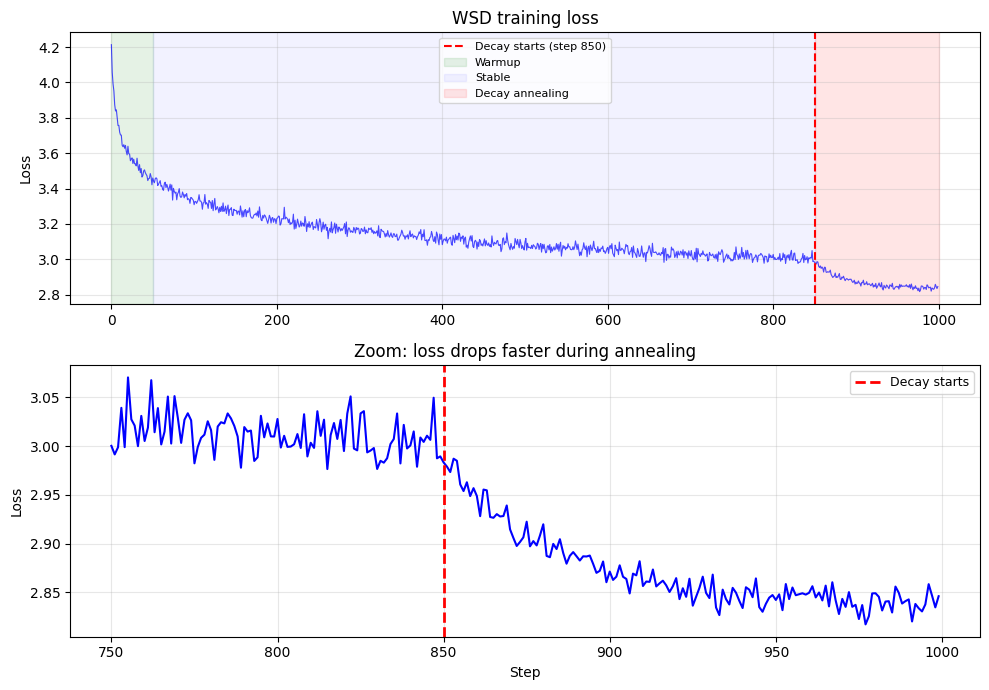

注意 decay 阶段（红色区域）的下降斜率明显变陡——这就是退火的威力。


In [5]:
# === 退火可视化 ===
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# 上图：完整 loss 曲线
ax = axes[0]
ax.plot(steps, loss, 'b-', lw=0.8, alpha=0.7)
ax.axvline(x=stable_end, color='red', ls='--', lw=1.5, label=f'Decay starts (step {stable_end})')
ax.axvspan(0, 50, alpha=0.1, color='green', label='Warmup')
ax.axvspan(50, stable_end, alpha=0.05, color='blue', label='Stable')
ax.axvspan(stable_end, 1000, alpha=0.1, color='red', label='Decay annealing')
ax.set_ylabel('Loss')
ax.set_title('WSD training loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 下图：放大 decay
ax = axes[1]
ax.plot(steps[750:], loss[750:], 'b-', lw=1.5)
ax.axvline(x=stable_end, color='red', ls='--', lw=2, label='Decay starts')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Zoom: loss drops faster during annealing')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("注意 decay 阶段（红色区域）的下降斜率明显变陡——这就是退火的威力。")


## 4. Mid-Training 数据策略：退火阶段该喂什么？

退火阶段不只是 LR 在降——**数据也在切换。**

直觉：就像考试前一周的「冲刺复习」——不再刷模拟卷（粗数据），而是看错题本和重点笔记（精数据）。

MiniCPM 的消融实验对比了三种策略：

| 策略 | Stable 阶段数据 | Decay 阶段数据 | 效果 |
|:---|:---|:---|:---|
| A: 不切换 | CC+Code+Books | 同左（粗数据） | baseline |
| B: 退火后 SFT | CC+Code+Books | 同 A，退火后再做 SFT | 较好 |
| C: **退火即混入** | CC+Code+Books | **CC+Code+Books + 高质量数据** | **最好** |

策略 C 为什么最好？
- 退火初期 LR 还比较大 → 模型有「余力」吸收新数据模式
- 退火后期 LR 很小 → 精细收敛，把新模式「焊死」在参数里
- 等于用 LR 递减的过程同步完成了「学习新内容 + 巩固旧知识」

In [6]:
# === Decay 阶段数据配比手算 ===
print("=== 退火阶段数据配比方案 ===")
print()

# 场景：2.4B 模型，总共 1.2T tokens
# Stable: 1T（粗数据）  Decay: 200B（粗+精混合）
decay_total = 200  # B tokens

schemes = [
    ("不切换",        100,  0,  0,  0),
    ("保守混合",       70, 10, 10, 10),
    ("均衡混合",       50, 20, 15, 15),
    ("激进混合",       30, 30, 20, 20),
]

print(f"{'方案':<12s} {'粗数据':>8s} {'Wiki':>8s} {'SFT':>8s} {'指令':>8s} {'评价'}")
print("-" * 60)
for name, coarse, wiki, sft, inst in schemes:
    c = decay_total * coarse / 100
    w = decay_total * wiki / 100
    s = decay_total * sft / 100
    i = decay_total * inst / 100
    print(f"{name:<12s} {c:>6.0f}B  {w:>6.0f}B  {s:>6.0f}B  {i:>6.0f}B  ", end="")
    if coarse == 100:
        print("baseline")
    elif coarse >= 50:
        print("推荐")
    else:
        print("领域学到了，但遗忘风险高")

print()
print("黄金法则：")
print("  1. 粗数据（CC+Code）不能丢 → 防止遗忘预训练知识")
print("  2. 高质量数据占 30-50% → 让退火真正发挥「精调」效果")
print("  3. 高质量数据超 50% 会把模型「带偏」→ 忘记多样化知识")

=== 退火阶段数据配比方案 ===

方案                粗数据     Wiki      SFT       指令 评价
------------------------------------------------------------
不切换             200B       0B       0B       0B  baseline
保守混合            140B      20B      20B      20B  推荐
均衡混合            100B      40B      30B      30B  推荐
激进混合             60B      60B      40B      40B  领域学到了，但遗忘风险高

黄金法则：
  1. 粗数据（CC+Code）不能丢 → 防止遗忘预训练知识
  2. 高质量数据占 30-50% → 让退火真正发挥「精调」效果
  3. 高质量数据超 50% 会把模型「带偏」→ 忘记多样化知识


/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49770/3667986375.py:22: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49770/3667986375.py:22: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49770/3667986375.py:22: UserWarning: Glyph 25442 (\N{CJK UNIFIED IDEOGRAPH-6362}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49770/3667986375.py:22: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49770/3667986375.py:22: UserWarning: Glyph 23432 (\N{CJK UNIFIED IDEOGRAPH-5B88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6

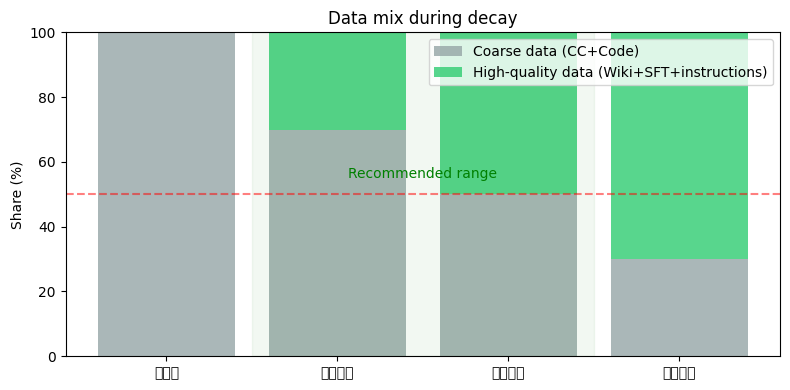

In [7]:
# === 数据配比可视化 ===
fig, ax = plt.subplots(figsize=(8, 4))

names = ['不切换', '保守混合', '均衡混合', '激进混合']
coarse = [100, 70, 50, 30]
quality = [0, 30, 50, 70]  # 高质量数据总和

x = np.arange(len(names))
ax.bar(x, coarse, label='Coarse data (CC+Code)', color='#95a5a6', alpha=0.8)
ax.bar(x, quality, bottom=coarse, label='High-quality data (Wiki+SFT+instructions)', color='#2ecc71', alpha=0.8)
ax.set_ylabel('Share (%)')
ax.set_title('Data mix during decay')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.axhline(y=50, color='red', ls='--', alpha=0.5, label='50% reference line')

# 标注推荐区间
ax.axvspan(0.5, 2.5, alpha=0.05, color='green')
ax.text(1.5, 55, 'Recommended range', ha='center', fontsize=10, color='green')

plt.tight_layout()
plt.show()


## 5. 持续预训练（CPT）：把通用模型变成领域专家

退火和数据切换是「预训练内部」的策略——它们不改变模型的定位。但还有一个更大的场景：

> **你已经有了一个通用 LLM（比如 LLaMA 3），现在想让它学会医疗、法律或金融领域的专业知识。**

这叫 **Continual Pretraining (CPT)**，也叫持续预训练。

### 5.1 核心挑战：灾难性遗忘

CPT 最大的风险是灾难性遗忘。模型在通用数据上预训练时学会了广泛的知识——语法、常识、推理、多语言。当你只用领域数据继续训练时，模型会逐渐「忘记」通用知识，因为新的梯度更新覆盖了旧的知识。

打个比方：一个学了三年英语的人，如果之后三个月只学法语，法语进步了，但英语会退步。如果每天同时复习英语，两门语言就都能保持。

CPT 要做的事情完全一样——在学新领域的同时，保留通用能力。

### 5.2 数据配比的黄金法则</cell>

In [8]:
# === CPT 数据策略手算 ===
print("=== CPT 数据配比：领域数据 vs 通用数据 ===")
print()

cpt_total = 50  # B tokens

strategies = [
    ("纯领域数据",    100,   0, "遗忘严重：模型只会写病历"),
    ("领域为主",       70,  30, "通用能力部分退化"),
    ("均衡混合",       50,  50, "推荐：两不误"),
    ("保守混合",       30,  70, "领域学习不充分"),
]

print(f"总 CPT 数据: {cpt_total}B tokens")
print()
print(f"{'策略':<14s} {'领域':>8s} {'通用':>8s} {'评价'}")
print("-" * 50)
for name, domain, general, note in strategies:
    d = cpt_total * domain / 100
    g = cpt_total * general / 100
    print(f"{name:<14s} {d:>6.0f}B  {g:>6.0f}B  {note}")

print()
print("黄金法则：领域数据 : 通用数据 ≈ 1:1 到 2:1")
print("通用数据的作用 = 「锚」，防止模型忘记原来会的东西")

=== CPT 数据配比：领域数据 vs 通用数据 ===

总 CPT 数据: 50B tokens

策略                   领域       通用 评价
--------------------------------------------------
纯领域数据              50B       0B  遗忘严重：模型只会写病历
领域为主               35B      15B  通用能力部分退化
均衡混合               25B      25B  推荐：两不误
保守混合               15B      35B  领域学习不充分

黄金法则：领域数据 : 通用数据 ≈ 1:1 到 2:1
通用数据的作用 = 「锚」，防止模型忘记原来会的东西


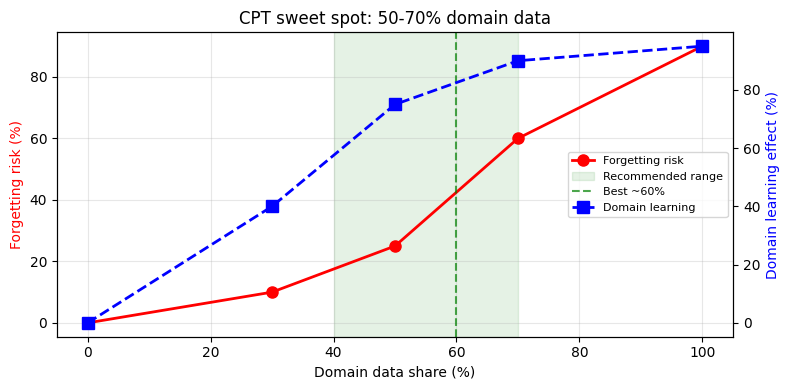

红色上升 = 遗忘越多，蓝色上升 = 学得越好
交叉的绿色区域就是甜蜜点——两不误。


In [9]:
# === 遗忘 vs 学习：甜蜜点可视化 ===
fig, ax = plt.subplots(figsize=(8, 4))

domain_pct = np.array([0, 30, 50, 70, 100])
forget_risk = np.array([0, 10, 25, 60, 90])  # 遗忘风险
domain_learn = np.array([0, 40, 75, 90, 95])  # 领域学习效果

ax2 = ax.twinx()
ax.plot(domain_pct, forget_risk, 'r-o', lw=2, ms=8, label='Forgetting risk')
ax2.plot(domain_pct, domain_learn, 'b--s', lw=2, ms=8, label='Domain learning')

ax.axvspan(40, 70, alpha=0.1, color='green', label='Recommended range')
ax.axvline(x=60, color='green', ls='--', alpha=0.7, label='Best ~60%')

ax.set_xlabel('Domain data share (%)')
ax.set_ylabel('Forgetting risk (%)', color='red')
ax2.set_ylabel('Domain learning effect (%)', color='blue')
ax.set_title('CPT sweet spot: 50-70% domain data')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("红色上升 = 遗忘越多，蓝色上升 = 学得越好")
print("交叉的绿色区域就是甜蜜点——两不误。")


### 5.2 LoRA 做 CPT：天然防遗忘 + 省显存

CPT 的两条路：

| 方法 | 可训练参数 | 防遗忘 | 显存 (7B) |
|:---|:---|:---|:---|
| 全量 CPT | 全部 7B | 差（所有参数都在变） | ~120 GB |
| **LoRA CPT** | ~21M (0.3%) | **好（原始权重冻结）** | **~15 GB** |

LoRA 天然防遗忘：原始权重 W 完全不动，只有小旁路 AB 在变。
等于在原来的地基上加一个小阁楼——地基完好无损。

In [10]:
# === CPT 显存对比 ===
print("=== CPT 显存对比（7B 模型）===")
print()
print(f"{'方法':<20s} {'基座':>8s} {'训练参数':>10s} {'优化器':>10s} {'总计':>8s}")
print("-" * 60)

# 全量 CPT
print(f"{'全量 CPT':<20s} {'14 GB':>8s} {'7000M':>10s} {'84 GB':>10s} {'~120 GB':>8s}")

# LoRA CPT
print(f"{'LoRA CPT (r=16)':<20s} {'14 GB':>8s} {'~21M':>10s} {'~1 GB':>10s} {'~15 GB':>8s}")

# QLoRA CPT
print(f"{'QLoRA CPT (4bit)':<20s} {'3.5 GB':>8s} {'~21M':>10s} {'~1 GB':>10s} {'~6 GB':>8s}")

print()
print("QLoRA 只需要 6GB → 一张 RTX 3060 就能做 7B 模型的领域 CPT！")
print()
print("LoRA 做 CPT 的核心优势：")
print("  1. 原始权重冻结 → 地基不动 → 通用知识不丢失")
print("  2. 只训旁路 AB → 显存极省")
print("  3. 训完 merge → 推理零开销（和普通模型一样快）")
print()
print("注意：如果 CPT 数据量很大（>100B），LoRA 的低秩可能不够。")
print("这时可以考虑用更大的 r（如 64 或 128），或者直接全量 CPT。")

=== CPT 显存对比（7B 模型）===

方法                         基座       训练参数        优化器       总计
------------------------------------------------------------
全量 CPT                  14 GB      7000M      84 GB  ~120 GB
LoRA CPT (r=16)         14 GB       ~21M      ~1 GB   ~15 GB
QLoRA CPT (4bit)       3.5 GB       ~21M      ~1 GB    ~6 GB

QLoRA 只需要 6GB → 一张 RTX 3060 就能做 7B 模型的领域 CPT！

LoRA 做 CPT 的核心优势：
  1. 原始权重冻结 → 地基不动 → 通用知识不丢失
  2. 只训旁路 AB → 显存极省
  3. 训完 merge → 推理零开销（和普通模型一样快）

注意：如果 CPT 数据量很大（>100B），LoRA 的低秩可能不够。
这时可以考虑用更大的 r（如 64 或 128），或者直接全量 CPT。


## 6. 全景：从预训练到 CPT 的完整训练策略

把本 Part 学的所有内容串成一条线：

```
┌─────────────────────────────────────────────────────────────────┐
│                   LLM 的完整训练生命周期                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  1. 预训练 (Pretraining)                                        │
│     数据：Common Crawl + Wiki + Code + Books (10T+ tokens)       │
│     调度器：WSD (stable 阶段，LR 恒定)                           │
│     ↓                                                           │
│                                                                 │
│  2. Mid-Training 退火 (Annealing)                               │
│     数据：混入 30-50% 高质量数据 (Wiki/SFT/指令)                  │
│     调度器：WSD decay 阶段，LR 递减                              │
│     ↓                                                           │
│                                                                 │
│  3. 持续预训练 (CPT) — 可选                                      │
│     场景：把通用模型适配到特定领域                                │
│     数据：领域 50-70% + 通用 30-50%                              │
│     方法：LoRA/QLoRA（省显存 + 防遗忘）                          │
│     ↓                                                           │
│                                                                 │
│  4. SFT + RLHF (后续 Part)                                      │
│     教模型「怎么回答问题」                                        │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**每一步都是在上一步的基础上「加餐」，不是推翻重来。**

## 小结

确认你已经搞懂了这些：

- [ ] 1. Cosine 调度器的局限：训练步数提前定死，无法续训
- [ ] 2. WSD 三阶段：Warmup(热身) → Stable(恒定) → Decay(退火)
- [ ] 3. WSD 的核心优势：Stable 阶段 LR 恒定 → 随时可停，随时续训
- [ ] 4. 退火为什么有效：方向已确定 + 步子变小更精准 + 高质量数据引导
- [ ] 5. Mid-Training 数据策略：退火阶段混入 30-50% 高质量数据，效果最好
- [ ] 6. CPT 的核心挑战：灾难性遗忘——学新的忘旧的
- [ ] 7. CPT 数据黄金法则：领域 50-70% + 通用 30-50%，通用数据是「锚」
- [ ] 8. LoRA 做 CPT：冻结原始权重 = 地基不动 + 显存省到 1/8
- [ ] 9. 完整训练生命周期：预训练 → 退火 → CPT(可选) → SFT → RLHF

**一句话总结**：预训练不是终点，而是起点。WSD 让训练可以随时续，退火让最后 10% 的计算发挥最大效果，CPT 让通用模型变成领域专家——三者合在一起，就是 2024 年的训练标准配方。